# Example: Delivery fleet data (By Ashwani Kumar)

As an example, we'll show how the $K$-means algorithm works with a sample dataset of delivery fleet driver data.  

For the sake of simplicity, we'll only be looking at two driver features:
- **mean distance driven per day** and
- **mean percentage of time a driver was $>5$ mph over the speed limit**.

In general, this algorithm can be used for any number of features, **so long as the number of data samples is much greater than the number of features**.

In [ ]:
import pandas as pd
import numpy as np

# imports
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


## 1. Problem formulation
Find clusters

## 2 Data collection

Prompt: I have a file data_driver.csv. Load this into a pandas dataframe df.

In [ ]:
df = pd.read_csv("data_driver.csv")

df

,id,mean_dist_day,mean_over_speed_perc
0,3423311935,71.24,28
1,3423313212,52.53,25
2,3423313724,64.54,27
3,3423311373,55.69,22
4,3423310999,54.58,25
...,...,...,...
3995,3423310685,160.04,10
3996,3423312600,176.17,5
3997,3423312921,170.91,12
3998,3423313630,176.14,5


In [ ]:
# Prompt: Set 'id' as the index column
df = df.set_index('id')

# Display the DataFrame
print(df.head())

            mean_dist_day  mean_over_speed_perc
id                                             
3423311935          71.24                    28
3423313212          52.53                    25
3423313724          64.54                    27
3423311373          55.69                    22
3423310999          54.58                    25


In [ ]:
# prompt: display few beginning rows

print(df.head())

            mean_dist_day  mean_over_speed_perc
id                                             
3423311935          71.24                    28
3423313212          52.53                    25
3423313724          64.54                    27
3423311373          55.69                    22
3423310999          54.58                    25


In [ ]:
# Lets look at few last rows

print(df.tail())

            mean_dist_day  mean_over_speed_perc
id                                             
3423310685         160.04                    10
3423312600         176.17                     5
3423312921         170.91                    12
3423313630         176.14                     5
3423311533         168.03                     9


In [ ]:
# Lets look at few random rows

print(df.sample(10))

            mean_dist_day  mean_over_speed_perc
id                                             
3423312816          40.17                     2
3423311227          35.88                     4
3423310686          29.92                     4
3423311602         188.10                    15
3423313962          65.73                     5
3423311441         193.68                     8
3423313015          61.82                    23
3423311463          57.20                     7
3423312184         187.12                    99
3423313916          36.99                     3


## 3. Exploratory Data Analysis

In [ ]:
# 1) Prompt: Display data type, memory usage, etc
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 3423311935 to 3423311533
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   mean_dist_day         4000 non-null   float64
 1   mean_over_speed_perc  4000 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 93.8 KB


In [ ]:
# 2) Downcast numeric columns to reduce memory usage
df['mean_dist_day'] = pd.to_numeric(df['mean_dist_day'], downcast='float')
df['mean_over_speed_perc'] = pd.to_numeric(df['mean_over_speed_perc'], downcast='integer')

# Compare memory usage before and after
print(df.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 3423311935 to 3423311533
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   mean_dist_day         4000 non-null   float32
 1   mean_over_speed_perc  4000 non-null   int8   
dtypes: float32(1), int8(1)
memory usage: 50.8 KB
None


In [ ]:
# 3) How much memory reduction: 45%   --- Good
(93.8-50.8)/93.8

0.4584221748400853

In [ ]:
# 1) prompt: Display Descriptive stats
print(df.describe())

# observation for column mean_dist_day:
# 25% of data is below 45
# 50% of data is below 53
# 75% of data is below 65, etc...

       mean_dist_day  mean_over_speed_perc
count    4000.000000           4000.000000
mean       76.041527             10.721000
std        53.469563             13.708543
min        15.520000              0.000000
25%        45.247500              4.000000
50%        53.330002              6.000000
75%        65.632500              9.000000
max       244.789993            100.000000


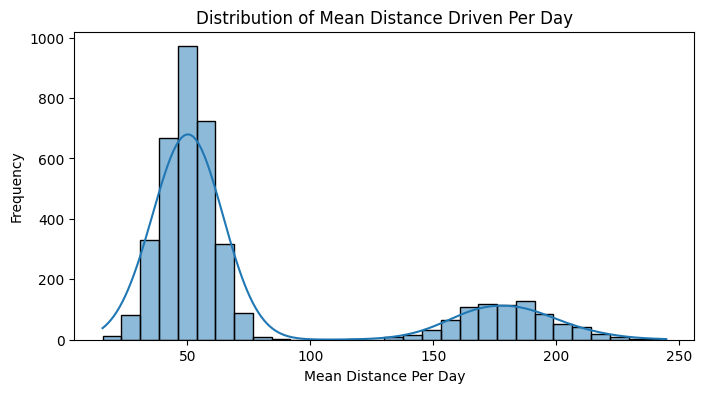

In [ ]:
# 2) prompt: plot Distribution of mean_dist_day

plt.figure(figsize=(8, 4))
sns.histplot(df['mean_dist_day'], bins=30, kde=True)
plt.title('Distribution of Mean Distance Driven Per Day')
plt.xlabel('Mean Distance Per Day')
plt.ylabel('Frequency')
plt.show()

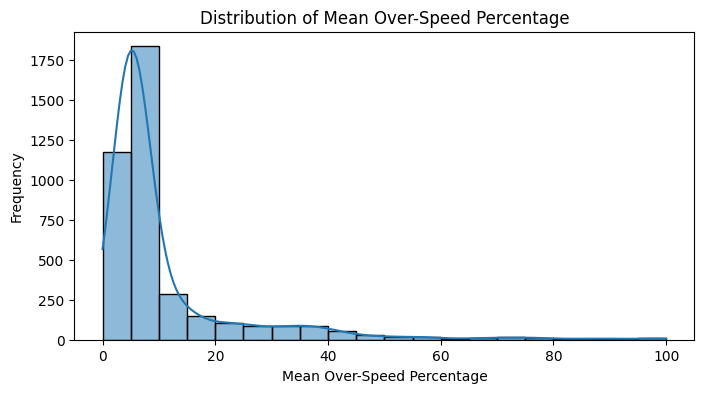

In [ ]:
# 3) prompt: plot Distribution of mean_over_speed_perc

plt.figure(figsize=(8, 4))
sns.histplot(df['mean_over_speed_perc'], bins=20, kde=True)
plt.title('Distribution of Mean Over-Speed Percentage')
plt.xlabel('Mean Over-Speed Percentage')
plt.ylabel('Frequency')
plt.show()

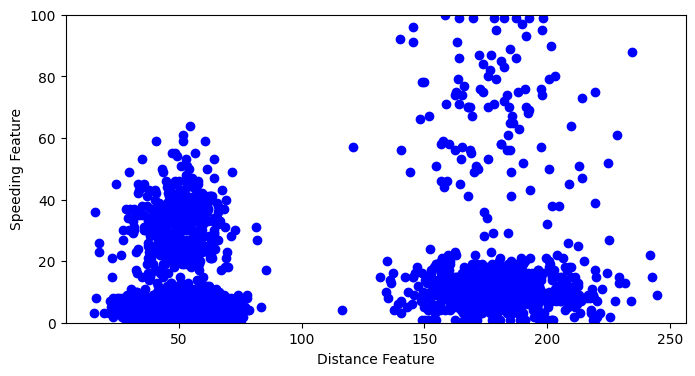

In [ ]:
# display relation between mean_dist_day and mean_over_speed_perc

plt.figure(figsize=(8, 4))
x = df['mean_dist_day']
y = df['mean_over_speed_perc']
plt.plot(x, y,'bo')
plt.xlabel('Distance Feature')
plt.ylabel('Speeding Feature')
plt.ylim(0,100)
plt.show()

The chart shows the results. Visually, you can see there seems to be two groups based on the distance feature.

Using domain knowledge of the dataset, we can infer that
- Group 1 is urban(densely populated) drivers and
- Group 2 is rural(less populated) drivers.

### Question: How many clusters do you see? 2, 3, or 4 ?

In [ ]:
# 1) Feature selection (assuming all columns except 'id' are relevant)
X = df.select_dtypes(include=[np.number]).to_numpy()  # Select only numerical columns
print(X)

[[ 71.24  28.  ]
 [ 52.53  25.  ]
 [ 64.54  27.  ]
 ...
 [170.91  12.  ]
 [176.14   5.  ]
 [168.03   9.  ]]


In [ ]:
# 2) Scale the features for better clustering performance

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 3) Lets see the actual feature and scaled feature

print(f"First 10 scaled features: \n{X_scaled[:10]}")

First 10 scaled features: 
[[-0.08981044  1.2606125 ]
 [-0.43977287  1.0417435 ]
 [-0.21513098  1.1876562 ]
 [-0.38066646  0.82287455]
 [-0.40142846  1.0417435 ]
 [-0.63841534 -0.05260152]
 [-0.32548797  0.67696184]
 [-0.44931218 -0.19851418]
 [-0.83780605  1.6983504 ]
 [-0.5935244   0.6040055 ]]


In [ ]:
## 4) OR you can look at unscaled/scaled feature side-by-side

print(X[0], "------>", X_scaled[0])
print(X[1], "------>", X_scaled[1])

[71.24 28.  ] ------> [-0.08981044  1.2606125 ]
[52.53 25.  ] ------> [-0.43977287  1.0417435 ]


# Find the optimal number of clusters

## Use the Elbow Method to Choose the Optimal Number of Clusters (`k`)

The Elbow Method helps determine a reasonable number of clusters for K-Means.

---

## Key Idea

K-Means minimizes the **within-cluster sum of squares (WCSS)**, also called **inertia**.

As the number of clusters increases:

* WCSS always decreases.
* The improvement becomes smaller after a certain point.

The “elbow” in the curve suggests a good choice for `k`.

---

## What K-Means Minimizes
$$WCSS = \sum_{k=1}^{K} \sum_{x_i \in C_k} ||x_i - \mu_k||^2$$

Where:
* $C_k$ is cluster $k$
* $\mu_k$ is the centroid of cluster $k$
* $x_i$ is a data point

---


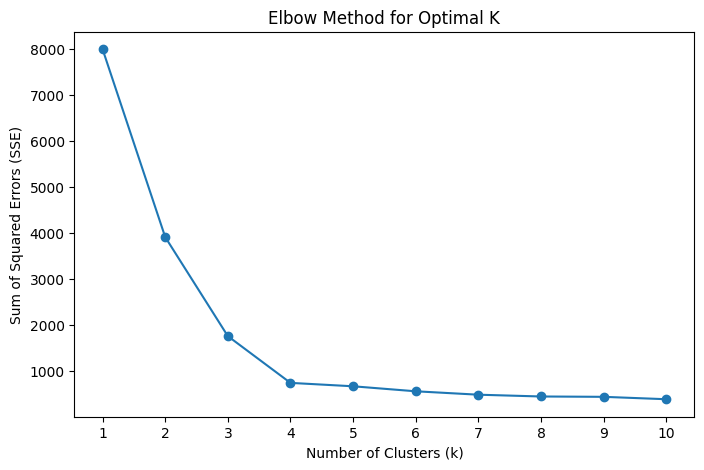

In [ ]:
# 1) Elbow method to determine the optimal K
kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42,
}

# A list holds the SSE(Sum of Squared Errors) values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(1, 11))
plt.show()

In [ ]:
# 2) We see from above that K=4, is the optimal
# (Error after k=4 decreases at lower rate)

# Apply KMeans clustering (K=4) with scaling
kmeans_with_scaling = KMeans(n_clusters=4,
                             random_state=42,
                             # Run the entire K-Means process 10 times from scratch with
                             # different initial starting points.
                             n_init=10
)
clusters = kmeans_with_scaling.fit_predict(X_scaled)

# Add cluster labels to the DataFrame
df["Cluster"] = clusters

Cluster Centers (With Scaling - Standardized Features):
[[-0.48678425 -0.4024968 ]
 [ 1.9526312  -0.01397141]
 [-0.4795233   1.5790927 ]
 [ 1.9040055   4.3458242 ]]


In [ ]:
# Lets see our df with clusters labels
df.head(15)

,mean_dist_day,mean_over_speed_perc,Cluster
id,,,
3423311935,71.239998,28,2
3423313212,52.529999,25,2
3423313724,64.540001,27,2
3423311373,55.689999,22,2
3423310999,54.580002,25,2
3423313857,41.910000,10,0
3423312432,58.639999,20,2
3423311434,52.020000,8,0
3423311328,31.250000,34,2


In [ ]:
# Print cluster centers (scaled)

print("Cluster Centers (With Scaling - Standardized Features):")
print(kmeans_with_scaling.cluster_centers_)

Cluster Centers (With Scaling - Standardized Features):
[[-0.48678425 -0.4024968 ]
 [ 1.9526312  -0.01397141]
 [-0.4795233   1.5790927 ]
 [ 1.9040055   4.3458242 ]]


In [ ]:
# 1) Lets see how many clusters and their corresponding counts
unique, counts = np.unique(kmeans_with_scaling.labels_, return_counts=True)

print("Cluster labels      :", unique)
print("Total cluster counts:", counts)

Cluster labels      : [0 1 2 3]
Total cluster counts: [2774  695  427  104]


In [ ]:
# 2) (OPTIONAL) Lets zip above and put them in dictionary: key=cluster-label : value=count on how many belong to each clusters
dict_data = dict(zip(unique, counts))
print(dict_data)

{0: 2774, 1: 695, 2: 427, 3: 104}


# Lets visualize this clusters

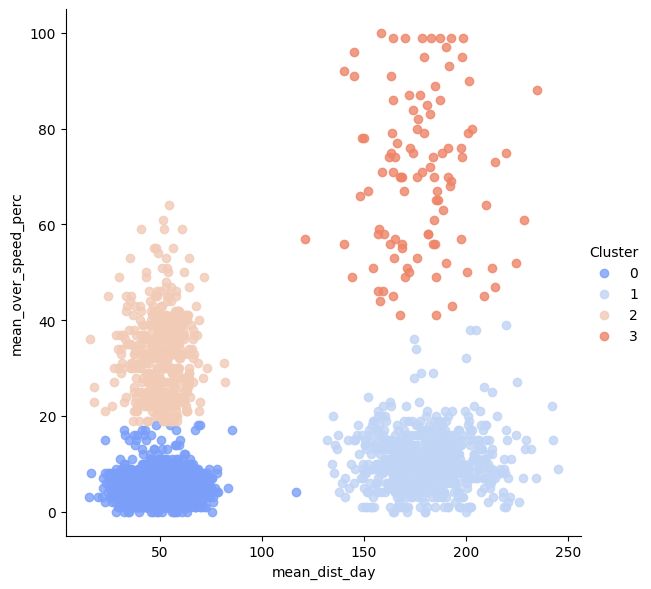

In [ ]:
import seaborn as sns

sns.lmplot(x='mean_dist_day', y='mean_over_speed_perc',
           data=df,
           hue='Cluster',
           palette='coolwarm',
           height=6,
           aspect=1,
           fit_reg=False
)

In [ ]:
# (OPTIONAL) Inertia is the sum of squared error (AKA WCSS) for each cluster.
# Therefore the smaller the inertia the denser the cluster(closer together all the points are)

print(kmeans_with_scaling.inertia_)

739.153564453125


# observation:

### Cluster 0: Low Distance – Low Speeding
- mean_dist_day: Low (e.g. < 70 km)
- mean_over_speed_perc: Low (e.g. < 20%)
- Interpretation: These are conservative or occasional drivers. They don’t drive far, and they rarely exceed the speed limit.

### Cluster 1: High Distance – Low Speeding
- mean_dist_day: High (e.g. > 65 km)
- mean_over_speed_perc: Low (e.g. < 20%)
- Interpretation: Likely professional or disciplined drivers—they drive a lot, but stay within speed limits. Possibly truck drivers or safety-focused workers.

### Cluster 2: Low Distance – Moderate Speeding
- mean_dist_day: ~50–60 km
- mean_over_speed_perc: ~20–25%
- Interpretation: These are typical daily drivers, like office workers or regular commuters. Balanced driving patterns.

### Cluster 3: High Distance – High Speeding
- mean_dist_day: High (e.g. > 65 km)
- mean_over_speed_perc: High (e.g. > 27%)
- Interpretation: These are likely aggressive, long-distance drivers, possibly rideshare drivers, couriers, or people commuting long distances who often drive fast.

---
## How can we use above information ?
If you are insurance company,
- you can charge **high** from people in cluster 3.
- You can charge **low** from people who are in cluster 0.


In [ ]:
# Now I want to see my data points with their cluster labels:
print(df)

            mean_dist_day  mean_over_speed_perc  Cluster
id                                                      
3423311935      71.239998                    28        2
3423313212      52.529999                    25        2
3423313724      64.540001                    27        2
3423311373      55.689999                    22        2
3423310999      54.580002                    25        2
...                   ...                   ...      ...
3423310685     160.039993                    10        1
3423312600     176.169998                     5        1
3423312921     170.910004                    12        1
3423313630     176.139999                     5        1
3423311533     168.029999                     9        1

[4000 rows x 3 columns]


In [ ]:
# lets print the 1st cluster
print(df[df['Cluster'] == 0])

            mean_dist_day  mean_over_speed_perc  Cluster
id                                                      
3423313857      41.910000                    10        0
3423311434      52.020000                     8        0
3423312268      55.150002                    18        0
3423312113      45.750000                    16        0
3423313389      61.689999                    12        0
...                   ...                   ...      ...
3423314346      39.389999                     8        0
3423313451      46.849998                     7        0
3423313552      37.680000                     7        0
3423312998      50.560001                     5        0
3423314125     116.580002                     4        0

[2774 rows x 3 columns]


In [ ]:
# lets print the 2nd cluster
print(df[df['Cluster'] == 1])

            mean_dist_day  mean_over_speed_perc  Cluster
id                                                      
3423313932     199.809998                    32        1
3423313466     211.360001                     5        1
3423311847     208.470001                    26        1
3423311045     186.279999                     4        1
3423313048     162.559998                    23        1
...                   ...                   ...      ...
3423310685     160.039993                    10        1
3423312600     176.169998                     5        1
3423312921     170.910004                    12        1
3423313630     176.139999                     5        1
3423311533     168.029999                     9        1

[695 rows x 3 columns]


In [ ]:
# lets print the 3rd cluster
print(df[df['Cluster'] == 2])

            mean_dist_day  mean_over_speed_perc  Cluster
id                                                      
3423311935      71.239998                    28        2
3423313212      52.529999                    25        2
3423313724      64.540001                    27        2
3423311373      55.689999                    22        2
3423310999      54.580002                    25        2
...                   ...                   ...      ...
3423313624      49.259998                    26        2
3423312679      59.509998                    30        2
3423312640      46.119999                    33        2
3423311984      51.700001                    37        2
3423311513      40.040001                    35        2

[427 rows x 3 columns]


In [ ]:
# lets print the 4th cluster
print(df[df['Cluster'] == 3])

            mean_dist_day  mean_over_speed_perc  Cluster
id                                                      
3423314190     179.220001                    95        3
3423314144     192.339996                    69        3
3423314442     140.250000                    92        3
3423313001     184.279999                    70        3
3423311047     200.580002                    50        3
...                   ...                   ...      ...
3423313871     177.199997                    87        3
3423310955     182.399994                    83        3
3423314016     189.880005                    97        3
3423310913     214.169998                    73        3
3423311064     159.800003                    58        3

[104 rows x 3 columns]
